## 1. Import Libraries

In [1]:
# Import necessary libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import statsmodels.api as sm

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA
from linearmodels.panel import PanelOLS
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.feature_selection import mutual_info_regression

import warnings
warnings.filterwarnings('ignore')

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_rows', None)

## 2. Data Loading and Preprocessing

### 2.1 Data Loading

In [3]:
# Tickers for oil companies
stocks_tickers = ["XOM", "CVX", "BP", "SHEL", "SLB", "COP", "OXY"]
indices_tickers = ["USO", "DBO", "^XOI", "^GSPE"]
commodities_tickers = ["CL=F", "BZ=F", "NG=F", "HO=F", "RB=F"]
macro_tickers = ["DX-Y.NYB", "^TNX", "^GSPC", "^DJI", "^VIX"]
other_tickers = indices_tickers + commodities_tickers + macro_tickers
tickers = stocks_tickers + indices_tickers + commodities_tickers + macro_tickers

In [4]:
# Date Range
today_date = datetime.date.today()
start_date = today_date - datetime.timedelta(days=365)

# Downloading Data
df = yf.download(tickers, start=start_date, end=today_date, interval='1d')

[*********************100%***********************]  21 of 21 completed


### 2.2 Data Reshaping

In [5]:
# Reshaping DataFrame to long format
df = df['Close'].reset_index().melt(id_vars=['Date'], value_vars=tickers, var_name='Ticker', value_name='Close')
df.head()

,Date,Ticker,Close
0,2024-10-29,XOM,113.187454
1,2024-10-30,XOM,112.618050
2,2024-10-31,XOM,112.704903
3,2024-11-01,XOM,110.938759
4,2024-11-04,XOM,114.471046


In [6]:
# Rename columns for compatibility with StatsForecast
df = df.rename(columns={
    'Date': 'ds', 
    'Ticker': 'unique_id', 
    'Close': 'y'}
    )

In [7]:
# Fill missing values with forward-fill and backward-fill
df = df.groupby('unique_id', group_keys=False).apply(lambda g: g.bfill().ffill())

In [8]:
var_dict = {}
# Reshape into Panel DataFrame
# Merge each index series as exogenous variable
for i, index in enumerate(other_tickers):
    var_dict[f'X_{i}'] = index
    var = (
        df[df['unique_id'] == index][['ds', 'y']].rename(columns={'y': f'X_{i}'})
    )
    df = df.merge(var, on='ds', how='left')

# Drop index rows (keep only main companies)
df = df[~df['unique_id'].isin(other_tickers)].reset_index(drop=True)

In [ ]:
# Display variable dictionary
print(var_dict)

{'X_0': 'USO', 'X_1': 'DBO', 'X_2': '^XOI', 'X_3': '^GSPE', 'X_4': 'CL=F', 'X_5': 'BZ=F', 'X_6': 'NG=F', 'X_7': 'HO=F', 'X_8': 'RB=F', 'X_9': 'DX-Y.NYB', 'X_10': '^TNX', 'X_11': '^GSPC', 'X_12': '^DJI', 'X_13': '^VIX'}


### 2.3 Data Preprocessing

In [10]:
# Creating Lagged Dependent Variables
for lag in range(1, 6):
    df[f'y_lag_{lag}'] = df.groupby('unique_id')['y'].shift(lag)

# Creating Lagged Independent Variables
for lag in range(1,6):
    for i, index in enumerate(other_tickers):
        df[f'X_{i}_lag_{lag}'] = df.groupby('unique_id')[f'X_{i}'].shift(lag)

In [11]:
# Drop rows with NaN values due to lagging
df = df.dropna().reset_index(drop=True)

### 2.4 Feature Selection

In [12]:
X = df.drop(columns=['y', 'unique_id', 'ds'])
y = df['y']

# Calculate mutual information
mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Convert to DataFrame
mi_df = mi_series.reset_index()
mi_df.columns = ['Feature', 'MI_Score']

# Select significant features
feature_cols = mi_df.loc[mi_df['MI_Score'] >= 0.2, 'Feature'].tolist()

In [ ]:
# Get list of feature columns
basic_cols = ['ds', 'unique_id', 'y']
all_cols = basic_cols + feature_cols # + dummy_cols
var_cols = [col for col in feature_cols if col not in ['ds', 'unique_id', 'y']]
df = df[all_cols]
df.columns

Index(['ds', 'unique_id', 'y', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_4',
       'y_lag_5', 'X_3', 'X_9_lag_3', 'X_9_lag_1', 'X_9_lag_4', 'X_9',
       'X_11_lag_4', 'X_9_lag_5', 'X_11', 'X_9_lag_2', 'X_11_lag_1',
       'X_11_lag_5', 'X_11_lag_3', 'X_11_lag_2', 'X_2', 'X_12', 'X_3_lag_1',
       'X_12_lag_1', 'X_2_lag_1', 'X_12_lag_4', 'X_5', 'X_3_lag_2',
       'X_12_lag_5', 'X_5_lag_1'],
      dtype='object')

## 3. Model Training: Econometrics and Machine Learning

### 3.1 Data Preparation for Econometrics and Machine Learning Modeling

In [15]:
# Split into train and test sets
train = df.groupby('unique_id').apply(lambda g: g.iloc[:-7]).reset_index(drop=True)
test = df.groupby('unique_id').apply(lambda g: g.iloc[-7:]).reset_index(drop=True)

# Set date and unique_id as index
train = train.set_index(['unique_id', 'ds'])
test = test.set_index(['unique_id', 'ds'])

# Splitting Training into X and Y
Y_train = train['y']
X_train = train[var_cols]

### 3.2 Econometric Models to Predict Oil Stock Prices

In [17]:
# Fit Fixed Effects Model
model_fem = PanelOLS(Y_train, X_train, entity_effects=True, drop_absorbed=True, check_rank=False)
trained_fem = model_fem.fit()

# Get the model's residual
train['residual'] = trained_fem.resids

# Compute Predicted Y from Fixed Effects Model
X_test = test[var_cols]
test['Y_hat_fem'] = trained_fem.predict(X_test)

### 3.3 Machine Learning Models to Predict Residuals

In [18]:
# Assign and Train Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train[var_cols], train['residual'])

# Predict residuals on test set
test['residual_hat'] = rf.predict(test[var_cols])

### 3.4 Combining Econometric (Stock Price) and Machine Learning (Residuals) Predictions

In [19]:
# Combine Fixed Effects Predictions with Residual Predictions
test['Y_final_pred'] = test['Y_hat_fem'] + test['residual_hat']

### 3.5 Fixing Intercept of Our Predictions

In [66]:
# Fixing Intercept of Our Predictions
for i, stock in enumerate(stocks_tickers):
    # Calculate gap between last train y and first test y (intercept)
    last_train_y = float(train.loc[stock, 'y'].iloc[-1])
    first_test_y_mix = float(test.loc[stock, 'Y_final_pred'].iloc[0])
    first_test_y_fem = float(test.loc[stock, 'Y_hat_fem'].iloc[0])
    pcnt_gap_mix = (first_test_y_mix - last_train_y) / last_train_y * 100
    pcnt_gap_fem = (first_test_y_fem - last_train_y) / last_train_y * 100

    # Fixing intercept of Mixed Model Predictions
    if abs(pcnt_gap_mix) > 0.02:
        for j in range(len(test.loc[stock])):
            test.loc[stock, 'Y_final_pred'].iloc[j] = test.loc[stock, 'Y_final_pred'].iloc[j] - ((pcnt_gap_mix / 100) * last_train_y)

    # Fixing intercept of FEM Model Predictions
    if abs(pcnt_gap_fem) > 0.02:
        for j in range(len(test.loc[stock])):
            test.loc[stock, 'Y_hat_fem'].iloc[j] = test.loc[stock, 'Y_hat_fem'].iloc[j] - ((pcnt_gap_fem / 100) * last_train_y)

## 4. Visualization and Evaluation

### 4.1 Prediction Visualization

In [ ]:
df = df.set_index(['unique_id', 'ds'])

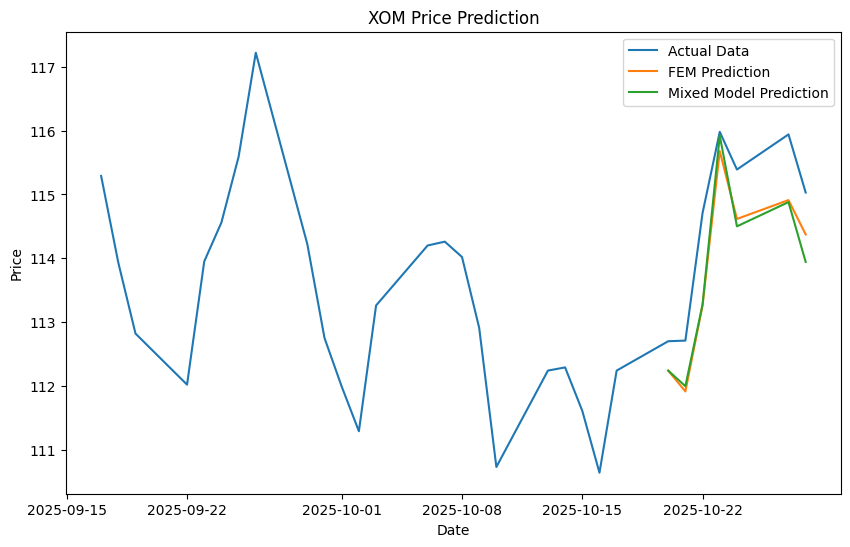

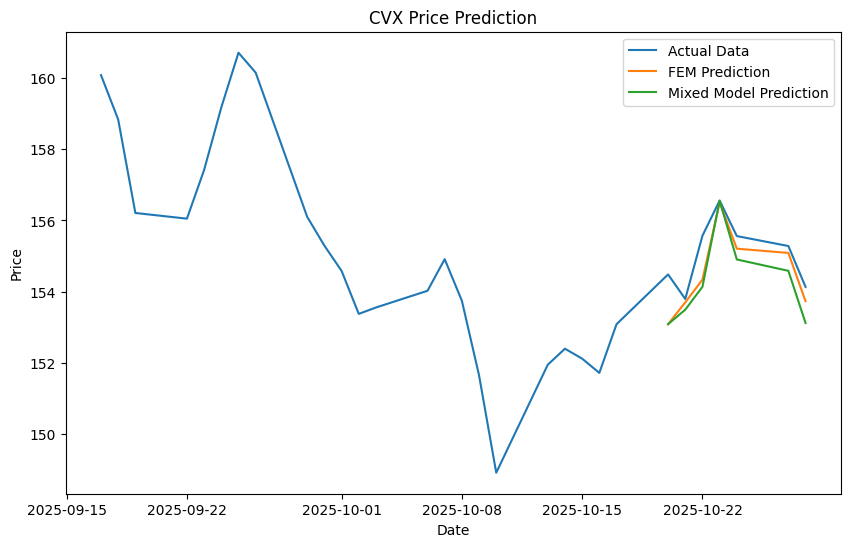

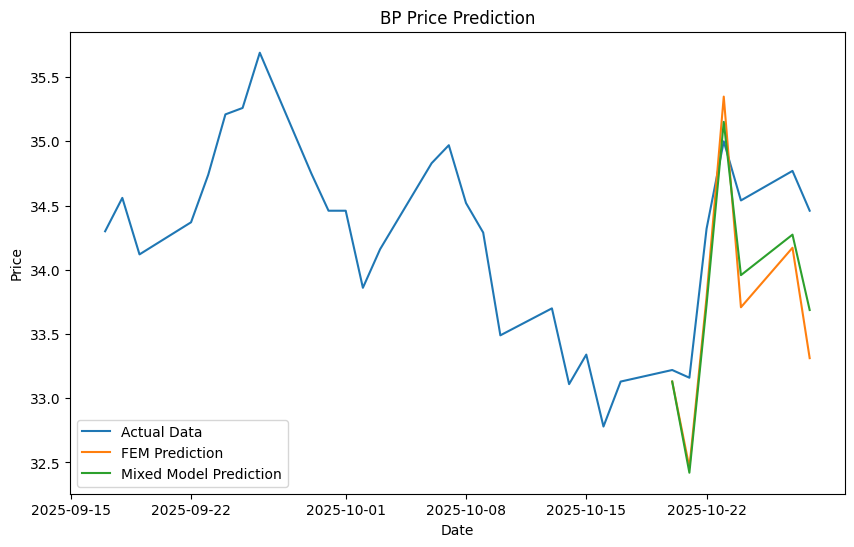

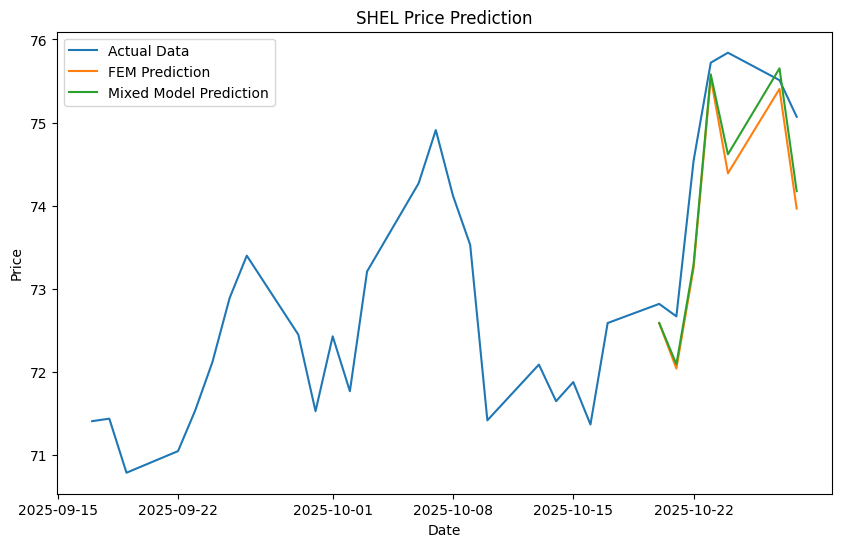

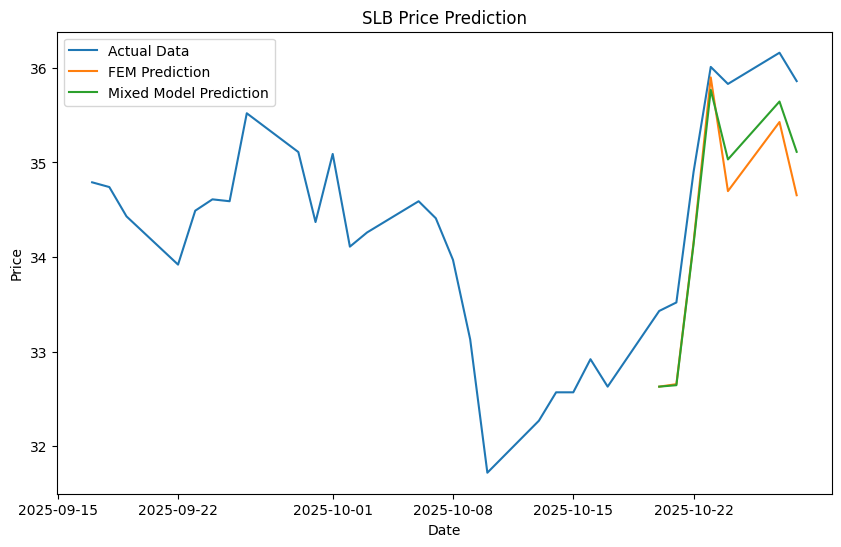

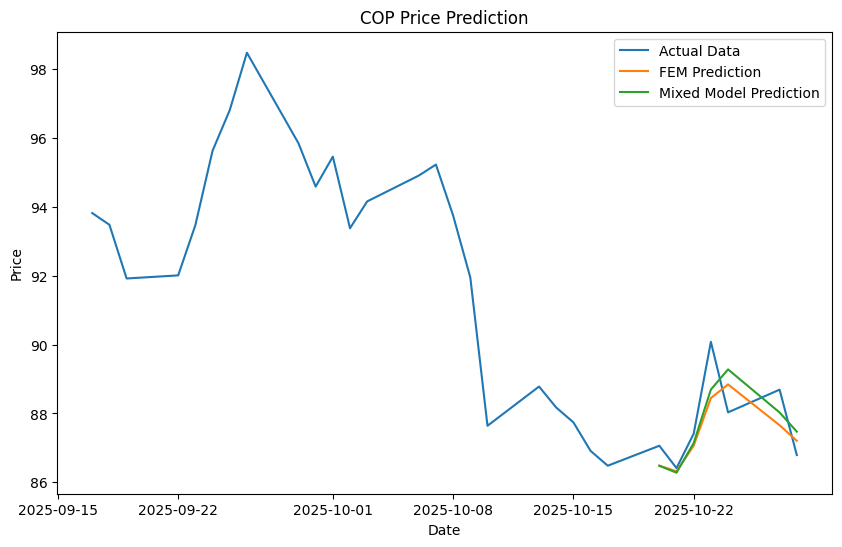

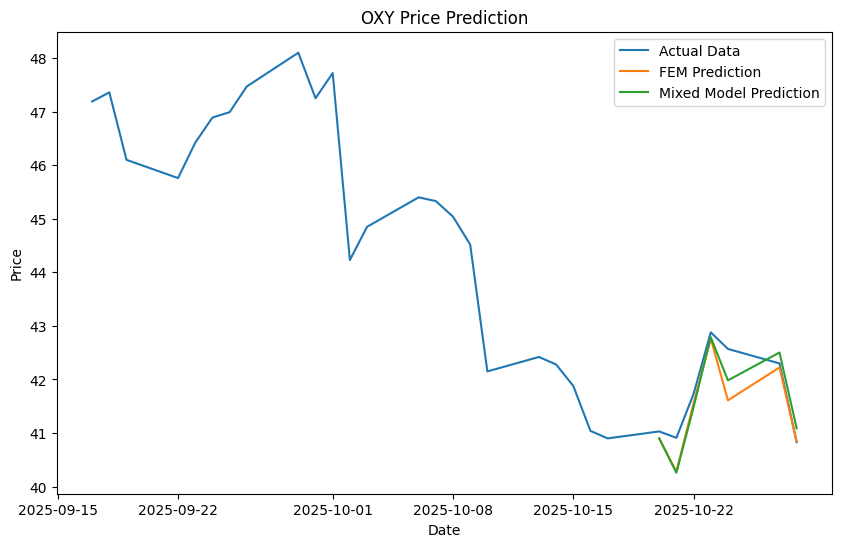

In [ ]:
# Plotting our Prediction
def plot_predictions(stock, shown_days=30):
    # last 30 days of actual data
    last_30 = df.loc[stock].sort_index().tail(shown_days)
    
    # forecast data for the stock
    forecast = test.xs(stock, level='unique_id').sort_index(level='ds')
    
    plt.figure(figsize=(10,6))

    # Choosing Data that we want to show
    plt.plot(last_30.index, last_30['y'], label='Actual Data')                     # Actual Data
    plt.plot(forecast.index, forecast['Y_hat_fem'], label='FEM Prediction')        # Fixed Effect Prediction
    plt.plot(forecast.index, forecast['Y_final_pred'], label='Mixed Model Prediction')  # Mixed Model Prediction

    plt.title(f'{stock} Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

# Looping through all stocks
for stock in stocks_tickers:
    plot_predictions(stock=stock)


### 4.2 Model Evaluation: Comparing Single and Mixed Models

In [70]:
# Evaluate R² Scores
r2_stage1 = r2_score(test['y'], test['Y_hat_fem'])
r2_final = r2_score(test['y'], test['Y_final_pred'])

# Print R² Scores and Comparison
print(f"R² Score - Fixed Effects Model: {r2_stage1:.4f}")
print(f"R² Score - Combined Model: {r2_final:.4f}")
if r2_final > r2_stage1:
    print("The combined model outperforms the fixed effects model alone.")
else:
    print("The fixed effects model alone outperforms the combined model.")

R² Score - Fixed Effects Model: 0.9997
R² Score - Combined Model: 0.9997
The combined model outperforms the fixed effects model alone.
